In this Notebook we experiment with various input images and rendering techniques for the background image of the welcome page of AUTOMATA & ACRI 2026.

What do I want?
- Import any image (any shape and file type) and output an image with the same shape
- Option to render white pixels as no pattern (instead of lowest-density diamond) with a particular cut-off value
- Option to choose maximal size of output image
- Option to choose colours

# Import packages and choose colours

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
# Add the src/ directory to the path
# TODO: this is not a very clean and robust way of importing
sys.path.append(os.path.abspath("../src"))

import mosaics

from PIL import Image
import cellpylib as cpl

# Define your custom colors using hex codes
from matplotlib.colors import LinearSegmentedColormap
ugent_blue = '#1E64C8'  # dark blue
ugent_yellow = '#FFD200'  # warm yellow

%load_ext autoreload
%autoreload 2

# Import and show original image

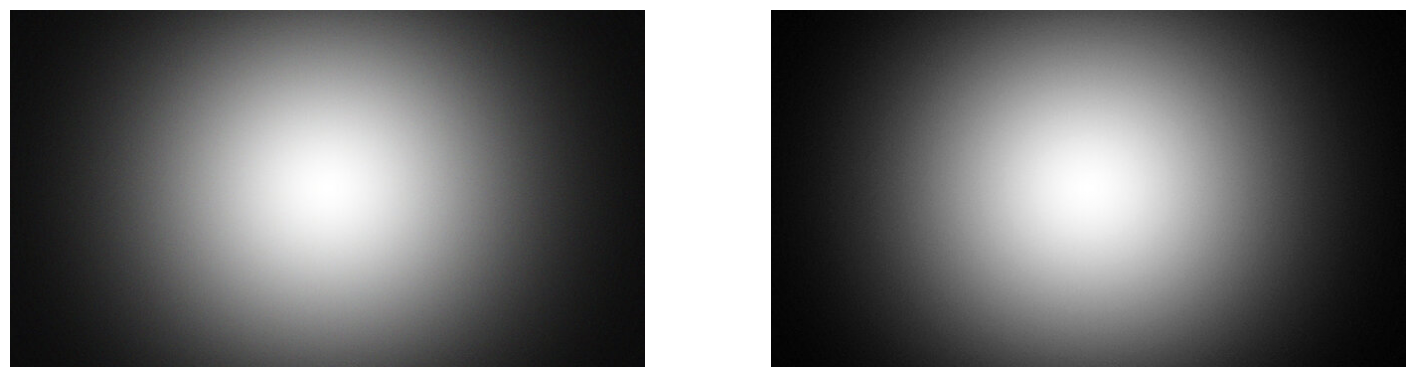

In [20]:
image_name = "gradient_centre"
extension = "jpg"
image_path = f"../input/images/{image_name}.{extension}"

img = Image.open(image_path)

fig, axs = plt.subplots(1,2,figsize=(18, 8))

axs[0].imshow(img)
axs[1].imshow(img.convert('L'), cmap='gray')
for ax in axs: ax.axis('off')



Mosaic shape: (152, 270)


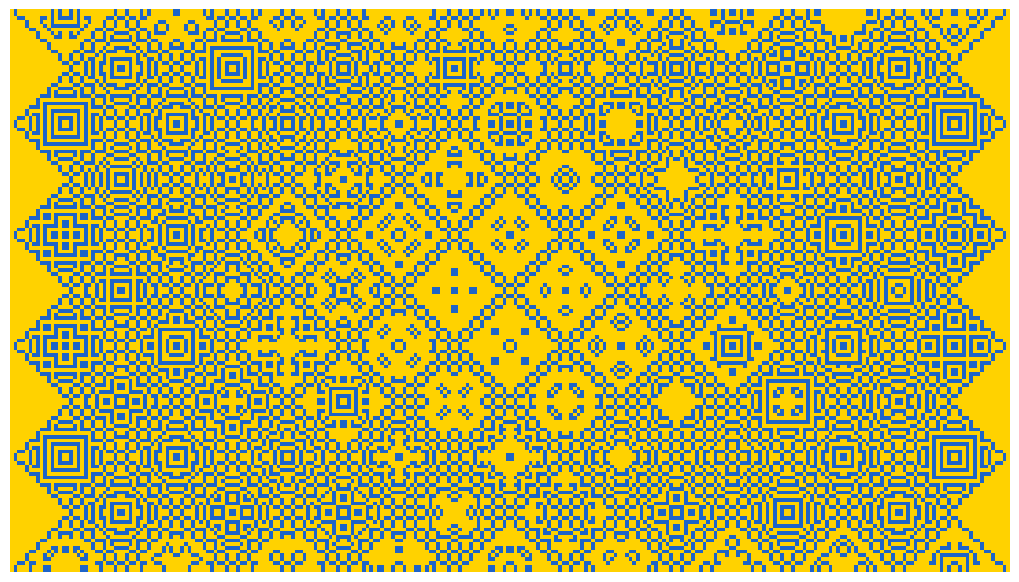

In [33]:
SAVEFIG = True

grid_size=12
level=5
invert=True
random=True
empty_tiles_cutoff=1.
horizontal_cropping = 0.0
bottom_cropping = 1.

# Load the image and convert it to a still life mosaic
img = mosaics.load_image(image_path, grayscale=True)
solution_mosaic = mosaics.image_to_still_life(image_path,
                                            grid_size=grid_size,
                                            level=level,
                                            invert=invert,
                                            random=random,
                                            empty_tiles_cutoff=empty_tiles_cutoff)

# crop horizontally
if horizontal_cropping:
    crop_pixels = int(horizontal_cropping * solution_mosaic.shape[1] / 2)
    solution_mosaic = solution_mosaic[:, crop_pixels:-crop_pixels]

# crop bottom
if bottom_cropping<1:
    crop_pixels = int(bottom_cropping * solution_mosaic.shape[0])
    solution_mosaic = solution_mosaic[:-crop_pixels, :]

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
fig_size = 10
fig.set_size_inches(fig_size, fig_size)
ax.axis('off')

# Create colormap with just these two colors
colors = [ugent_yellow, ugent_blue]
custom_cmap = LinearSegmentedColormap.from_list('custom', colors, N=2)

ax.imshow(solution_mosaic, cmap=custom_cmap, interpolation='none')
ax.axis('off')
# Remove padding
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

if SAVEFIG:
    dpi = solution_mosaic.shape[1] // fig_size
    plt.savefig(f'../output/{image_name}-mosaic-level{level}-gridsize{grid_size}.png',
                dpi=dpi, # 100 dpi × 10 inches = 1000 pixels
                bbox_inches='tight',
                pad_inches=0)
    # plt.close()

def list_denominators(n):
    """
    Return a sorted list of all positive divisors of the positive integer n.
    Raises ValueError for non-positive or non-integer input.
    """
    if not isinstance(n, int) or n <= 0:
        raise ValueError("n must be a positive integer")
    import math
    small, large = [], []
    i = 1
    while i * i <= n:
        if n % i == 0:
            small.append(i)
            j = n // i
            if j != i:
                large.append(j)
        i += 1
    return small + large[::-1]

print("Mosaic shape:", solution_mosaic.shape)
# print("Shape denominators:", list_denominators(solution_mosaic.shape[0]))

In [31]:
270/152

1.7763157894736843

In [25]:
# export as .cells file

filename="quicktest.cells"
mosaics.numpy_to_cells(solution_mosaic, filename=filename)